# 📊 Alpha101 因子系统研究 — 沪深300 多因子批量回测与对比

本 Notebook 演示使用 `AlphaResearcher` 对多个 Alpha 因子进行系统性研究：

1. **数据准备** — 一次加载沪深300日线数据
2. **批量回测** — `researcher.run_multiple([...])` 一行运行多个因子
3. **因子对比** — `researcher.compare_factors(results)` 净值曲线 + 绩效表
4. **深度分析** — `researcher.full_analysis(result)` 对最优因子展开完整分析

> **提示：** 所有公共逻辑已提取到框架中：
> - 截面选股策略 → `stockquant.strategy.AlphaFactorStrategy`
> - 研究工具 → `stockquant.research.AlphaResearcher`

## 1. 导入库与配置

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from stockquant.data.universe import Pool, StockUniverse
from stockquant.research import AlphaResearcher, AlphaBacktestResult

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

# ── 全局参数 ──────────────────────────────────────────────
START_DATE      = "2022-01-01"
END_DATE        = "2024-12-31"
INITIAL_CAPITAL = 1_000_000.0
MAX_POSITIONS   = 10        # 每个因子最多持仓只数
REBALANCE_FREQ  = 5         # 调仓频率（每 N 个交易日）

# ── 全部 101 个 Alpha 因子 ────────────────────────────────
ALPHA_IDS = list(range(1, 102))

print("✅ 模块导入成功")
print(f"   研究因子: 全部 {len(ALPHA_IDS)} 个 Alpha 因子（Alpha001 ~ Alpha101）")
print(f"   回测区间: {START_DATE} ~ {END_DATE}")

✅ 模块导入成功
   研究因子: 全部 101 个 Alpha 因子（Alpha001 ~ Alpha101）
   回测区间: 2022-01-01 ~ 2024-12-31


## 2. 加载沪深300数据（一次加载，全部因子复用）

> 数据只需加载一次，`AlphaResearcher` 持有 `dataset` 引用，所有因子回测复用同一份数据。

In [2]:
dataset = (
    StockUniverse()
    .scope(Pool.CSI300)
    .exclude(Pool.STAR, Pool.CHINEXT, Pool.BSE)
    .load(START_DATE, END_DATE, benchmark=Pool.CSI300)
)

print(dataset.summary())
print(f"\n基准指数: {dataset.benchmark_code}  |  {len(dataset.benchmark)} 条日线")

2026-03-08 06:56:12.601 | INFO     | stockquant.data.universe:_get_index_constituents:497 | 获取指数 000300 成分股
2026-03-08 06:56:18.128 | INFO     | stockquant.data.universe:_get_index_constituents:505 | 指数 000300 成分股: 280 只
2026-03-08 06:56:18.130 | INFO     | stockquant.data.universe:_apply_pool_exclude:453 | 排除 科创板: 移除 18 只
2026-03-08 06:56:18.132 | INFO     | stockquant.data.universe:_apply_pool_exclude:453 | 排除 创业板: 移除 32 只
2026-03-08 06:56:18.133 | INFO     | stockquant.data.universe:load:377 | 加载标的池: 沪深300（排除: 科创板, 创业板, 北交所） → 230 只
2026-03-08 06:56:18.175 | INFO     | stockquant.data.database:conn:46 | 已连接 DuckDB: /workspaces/stockQuant/stockquant/data/db/stockquant.duckdb
2026-03-08 06:56:18.235 | INFO     | stockquant.data.database:init_tables:110 | 数据库表初始化完成
2026-03-08 06:56:18.272 | INFO     | stockquant.data.data_manager:__init__:43 | 数据管理器初始化完成，主数据源: akshare
2026-03-08 06:56:19.244 | ERROR    | stockquant.data.source_akshare:get_daily_bars:83 | 获取 600930 日线数据失败: ('Connection 

📊 回测数据集摘要
   标的数量: 229 只（共请求 230 只）
   日期范围: 2022-01-01 ~ 2024-12-31
   基准指数: 000300（726 条）
   日线总条数: 164,404
   ⚠️ 缺失数据: ['600930']

基准指数: 000300  |  726 条日线


## 3. 创建 AlphaResearcher

`AlphaResearcher` 是研究流程的核心对象，持有数据集引用和因子面板缓存。

In [3]:
researcher = AlphaResearcher(
    dataset,
    initial_capital = INITIAL_CAPITAL,
    max_positions   = MAX_POSITIONS,
    rebalance_freq  = REBALANCE_FREQ,
)
print(f"✅ AlphaResearcher 创建完成")
print(f"   初始资金: ¥{INITIAL_CAPITAL:,.0f}  |  最多持仓: {MAX_POSITIONS} 只  |  调仓频率: {REBALANCE_FREQ} 日")

2026-03-08 06:56:21.842 | INFO     | stockquant.research.alpha_researcher:__init__:185 | AlphaResearcher 初始化: 229 只股票, max_pos=10, freq=5


✅ AlphaResearcher 创建完成
   初始资金: ¥1,000,000  |  最多持仓: 10 只  |  调仓频率: 5 日


## 4. 预计算因子面板（可选，节省后续重复计算时间）

`precompute_alphas` 批量计算并缓存指定因子面板，后续 `run_backtest` / `run_multiple` 直接读取缓存，无需重建引擎。

In [4]:
print("批量预计算因子面板...")
researcher.precompute_alphas(ALPHA_IDS)

# 查看某个因子面板概览
panel_1 = researcher.get_alpha_panel(1)
print(f"\nAlpha001 面板: {panel_1.shape}  (日期 × 股票)")
panel_1.tail(2).iloc[:, :5]

2026-03-08 06:56:21.854 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha001 面板...


批量预计算因子面板...


2026-03-08 06:56:22.776 | INFO     | stockquant.research.alpha_researcher:alpha_engine:199 | 构建 Alpha101 面板引擎（首次访问）...
2026-03-08 06:56:23.609 | INFO     | stockquant.data.database:conn:46 | 已连接 DuckDB: /workspaces/stockQuant/stockquant/data/db/stockquant.duckdb
2026-03-08 06:56:23.704 | INFO     | stockquant.indicators.alpha101.alpha101:_auto_load_stock_info:418 | 已从 stock_info 加载行业数据: 85 个行业
2026-03-08 06:56:23.707 | INFO     | stockquant.indicators.alpha101.alpha101:_auto_load_stock_info:430 | 已从 stock_info 加载流通市值数据
2026-03-08 06:56:24.131 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha001 计算完成，维度: (726, 229)
2026-03-08 06:56:24.132 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha002 面板...
2026-03-08 06:56:24.224 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha002 计算完成，维度: (726, 229)
2026-03-08 06:56:24.224 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha003 面板.

2026-03-08 06:56:41.705 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha004 计算完成，维度: (726, 229)
2026-03-08 06:56:41.706 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha005 面板...
2026-03-08 06:56:41.739 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha005 计算完成，维度: (726, 229)
2026-03-08 06:56:41.739 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha006 面板...
2026-03-08 06:56:41.809 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha006 计算完成，维度: (726, 229)
2026-03-08 06:56:41.810 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha007 面板...


2026-03-08 06:56:58.914 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha007 计算完成，维度: (726, 229)
2026-03-08 06:56:58.915 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha008 面板...
2026-03-08 06:56:58.951 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha008 计算完成，维度: (726, 229)
2026-03-08 06:56:58.951 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha009 面板...
2026-03-08 06:56:58.983 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha009 计算完成，维度: (726, 229)
2026-03-08 06:56:58.984 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha010 面板...
2026-03-08 06:56:59.023 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha010 计算完成，维度: (726, 229)
2026-03-08 06:56:59.024 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha011 面板...
2026-03-08 06:56:59.082 | INFO     | stockqu

...

2026-03-08 07:25:54.515 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha097 计算完成，维度: (726, 229)
2026-03-08 07:25:54.516 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha098 面板...


2026-03-08 07:26:12.951 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha098 计算完成，维度: (726, 229)
2026-03-08 07:26:12.952 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha099 面板...
2026-03-08 07:26:13.122 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha099 计算完成，维度: (726, 229)
2026-03-08 07:26:13.123 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha100 面板...


2026-03-08 07:28:20.139 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha100 计算完成，维度: (726, 229)
2026-03-08 07:28:20.140 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:217 | 计算 Alpha101 面板...
2026-03-08 07:28:20.143 | INFO     | stockquant.research.alpha_researcher:get_alpha_panel:221 | Alpha101 计算完成，维度: (726, 229)


✅ 已预计算 101 个因子面板（含缓存）          

Alpha001 面板: (726, 229)  (日期 × 股票)


code,000001,000002,000063,000100,000157
date,,,,,
2024-12-30,0.325991,-0.350220,0.019824,-0.35022,-0.350220
2024-12-31,0.191630,-0.072687,-0.233480,0.19163,0.444934


## 5. 批量回测所有研究因子

`run_multiple` 遍历 `ALPHA_IDS`，每个因子独立回测，输出进度 + 总收益，结果存入字典。

In [5]:
print(f"开始批量回测 {len(ALPHA_IDS)} 个 Alpha 因子...\n")
results = researcher.run_multiple(ALPHA_IDS)

开始批量回测 101 个 Alpha 因子...

[1/101] 回测 Alpha001...

2026-03-08 07:28:20.684 | INFO     | stockquant.backtest.engine:set_data:78 | 已加载 229 只标的，726 个交易日
2026-03-08 07:28:20.685 | INFO     | stockquant.research.alpha_researcher:run_backtest:308 | 运行回测: Alpha001  [2022-01-01 ~ 2024-12-31]
2026-03-08 07:28:20.688 | INFO     | stockquant.backtest.engine:run:104 | ====== 回测开始 ======
2026-03-08 07:28:20.690 | INFO     | stockquant.strategy.alpha_factor_strategy:initialize:62 | [Alpha001] 初始化完成 — max_pos=10, freq=5, target_pct=10.0%, ascending=False
2026-03-08 07:30:29.402 | INFO     | stockquant.backtest.engine:run:144 | ====== 回测结束 ======


  总收益: -53.34%
[2/101] 回测 Alpha002...

2026-03-08 07:30:29.753 | INFO     | stockquant.backtest.engine:set_data:78 | 已加载 229 只标的，726 个交易日
2026-03-08 07:30:29.754 | INFO     | stockquant.research.alpha_researcher:run_backtest:308 | 运行回测: Alpha002  [2022-01-01 ~ 2024-12-31]
2026-03-08 07:30:29.754 | INFO     | stockquant.backtest.engine:run:104 | ====== 回测开始 ======
2026-03-08 07:30:29.756 | INFO     | stockquant.strategy.alpha_factor_strategy:initialize:62 | [Alpha002] 初始化完成 — max_pos=10, freq=5, target_pct=10.0%, ascending=False
2026-03-08 07:32:37.801 | INFO     | stockquant.backtest.engine:run:144 | ====== 回测结束 ======


  总收益: -46.42%
[3/101] 回测 Alpha003...

...

  总收益: -9.66%
[100/101] 回测 Alpha100...

2026-03-08 10:49:23.734 | INFO     | stockquant.backtest.engine:set_data:78 | 已加载 229 只标的，726 个交易日
2026-03-08 10:49:23.735 | INFO     | stockquant.research.alpha_researcher:run_backtest:308 | 运行回测: Alpha100  [2022-01-01 ~ 2024-12-31]
2026-03-08 10:49:23.736 | INFO     | stockquant.backtest.engine:run:104 | ====== 回测开始 ======
2026-03-08 10:49:23.737 | INFO     | stockquant.strategy.alpha_factor_strategy:initialize:62 | [Alpha100] 初始化完成 — max_pos=10, freq=5, target_pct=10.0%, ascending=False
2026-03-08 10:51:23.111 | INFO     | stockquant.backtest.engine:run:144 | ====== 回测结束 ======


  总收益: -46.05%
[101/101] 回测 Alpha101...

2026-03-08 10:51:23.458 | INFO     | stockquant.backtest.engine:set_data:78 | 已加载 229 只标的，726 个交易日
2026-03-08 10:51:23.459 | INFO     | stockquant.research.alpha_researcher:run_backtest:308 | 运行回测: Alpha101  [2022-01-01 ~ 2024-12-31]
2026-03-08 10:51:23.459 | INFO     | stockquant.backtest.engine:run:104 | ====== 回测开始 ======
2026-03-08 10:51:23.461 | INFO     | stockquant.strategy.alpha_factor_strategy:initialize:62 | [Alpha101] 初始化完成 — max_pos=10, freq=5, target_pct=10.0%, ascending=False
2026-03-08 10:53:22.301 | INFO     | stockquant.backtest.engine:run:144 | ====== 回测结束 ======


  总收益: -48.76%

✅ 完成 101/101 个因子回测


## 6. 多因子绩效对比

`compare_factors` 同时输出：
- **净值曲线对比图**（所有因子 + 沪深300基准）
- **绩效对比表**（按夏普比率降序排列）

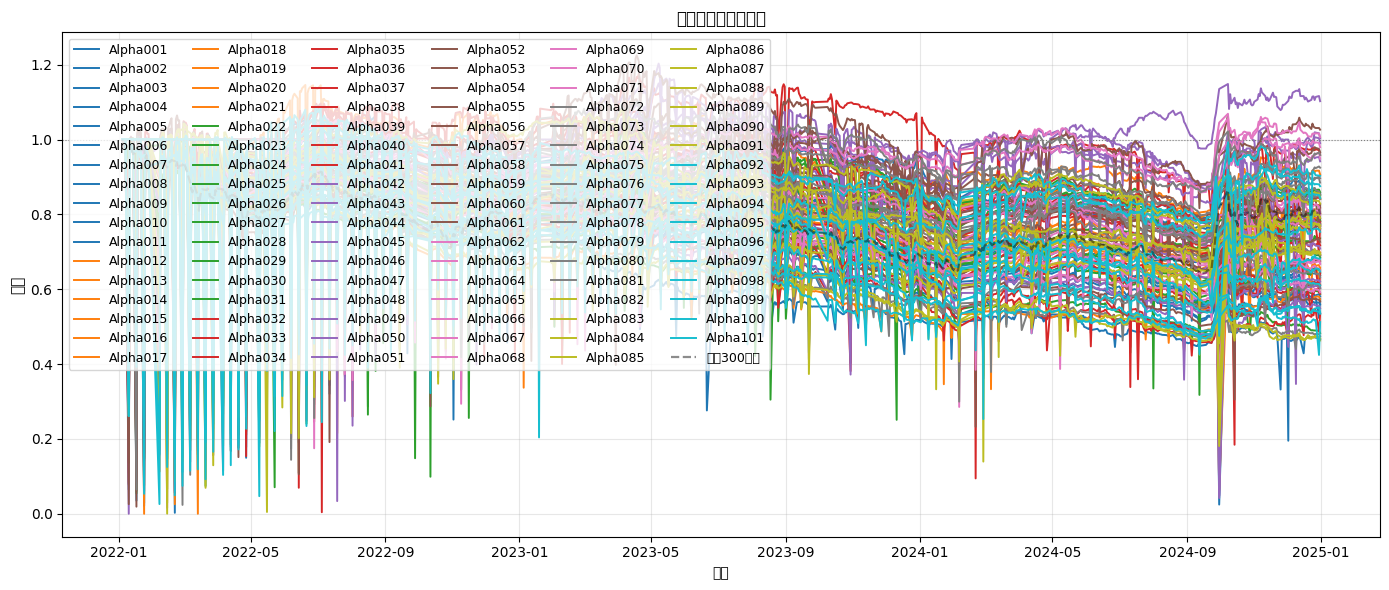

,总收益率,年化收益率,最大回撤,夏普比率,索提诺比率,卡玛比率,年化波动率,Alpha,Beta,总交易次数
因子,,,,,,,,,,
Alpha042,+10.28%,+3.46%,99.99%,0.00,0.00,0.03,434561.75%,+10.90%,-677.83,1382
Alpha014,-9.27%,-3.32%,99.99%,-0.00,-0.03,-0.03,403468.88%,+4.13%,-3076.59,2453
Alpha015,-42.75%,-17.60%,99.99%,-0.00,-0.09,-0.18,1029915.79%,-10.15%,-3866.71,2449
Alpha089,-53.13%,-23.13%,99.96%,-0.00,-0.12,-0.23,129046.88%,-15.68%,253.83,2386
Alpha032,-4.02%,-1.42%,99.58%,-0.00,-0.03,-0.01,13665.48%,+6.03%,-32.58,926
Alpha011,-42.51%,-17.48%,99.73%,-0.00,-0.09,-0.18,21312.37%,-10.03%,-52.89,2401
Alpha049,+0.35%,+0.12%,95.45%,-0.00,-0.02,0.00,1161.01%,+7.57%,10.94,1610
Alpha051,-0.97%,-0.34%,95.49%,-0.00,-0.02,-0.00,1139.20%,+7.11%,10.65,1586
Alpha048,-5.80%,-2.05%,96.60%,-0.00,-0.03,-0.02,1698.64%,+5.40%,0.98,1930


In [10]:
compare_df = researcher.compare_factors(results)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
compare_df

## 7. 数值型绩效对比表（便于排序/筛选）

`metrics_table` 返回数值型 DataFrame，可直接用 pandas 排序、筛选正 Alpha 因子等。

In [7]:
metrics = researcher.metrics_table(results)

# ── 筛选夏普比率 > 0 的因子 ─────────────────────────────
positive_sharpe = metrics[metrics["夏普比率"] > 0].sort_values("夏普比率", ascending=False)
print(f"夏普比率 > 0 的因子: {len(positive_sharpe)} / {len(metrics)} 个\n")
print(positive_sharpe[["年化收益率", "最大回撤", "夏普比率", "卡玛比率", "Alpha"]].to_string(
    float_format=lambda x: f"{x:+.3f}"
))

夏普比率 > 0 的因子: 1 / 101 个

          年化收益率   最大回撤   夏普比率   卡玛比率  Alpha
因子                                         
Alpha042 +0.035 +1.000 +0.000 +0.035 +0.109


## 8. 最优因子深度分析

自动挑选夏普比率最高的因子，调用 `full_analysis` 一键输出：净值图 + 月度热力图 + 持仓条形图 + 完整绩效表。

In [8]:
# 按夏普比率找出最优因子
best_id = metrics["夏普比率"].idxmax() if not metrics.empty else None

if best_id and best_id in results:
    best_result = results[int(best_id.replace("Alpha", ""))]
    print(f"最优因子: {best_id}  夏普比率={metrics.loc[best_id, '夏普比率']:.3f}")
    report_df = researcher.full_analysis(best_result)
else:
    print("⚠️ 无有效回测结果")

⚠️ 无有效回测结果


## 9. 指定单个因子深度分析

也可以手动指定任意 Alpha 编号进行深度分析：


════════════════════════════════════════════════════
  📊 Alpha001 — 完整分析报告
════════════════════════════════════════════════════


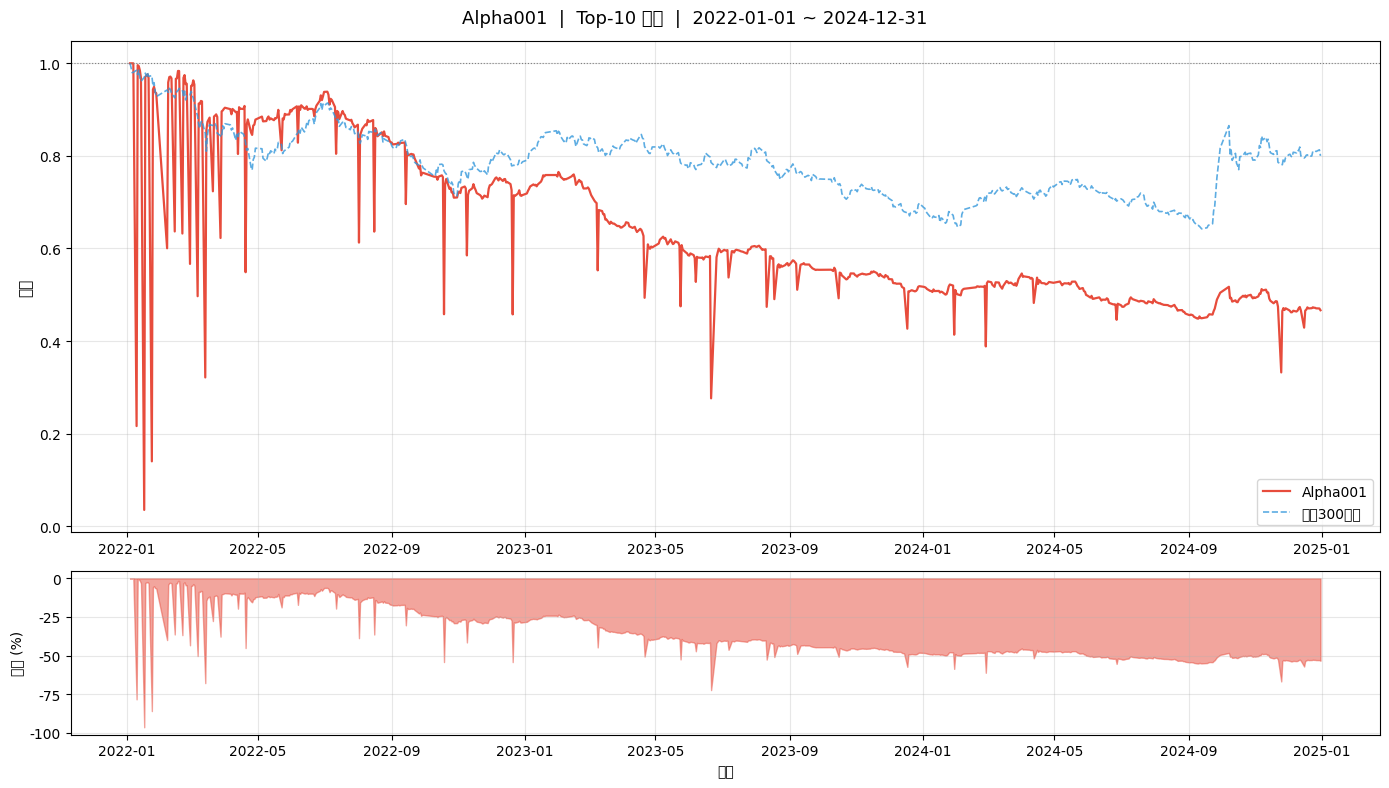

总收益率: -53.34% | 最大回撤: -96.48%


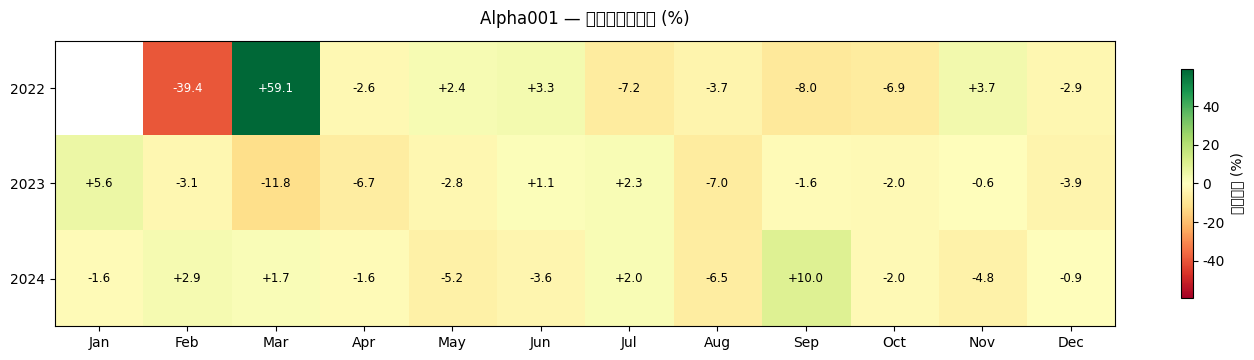

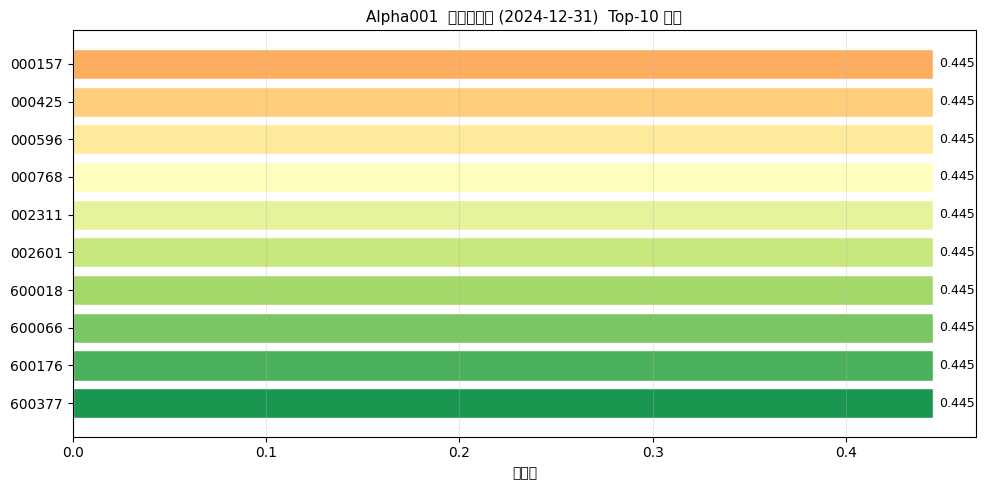

2026-03-08 10:53:25.098 | INFO     | stockquant.analysis.performance:full_report:193 | 绩效报告:
2026-03-08 10:53:25.099 | INFO     | stockquant.analysis.performance:full_report:195 |   总收益率: -53.34%
2026-03-08 10:53:25.099 | INFO     | stockquant.analysis.performance:full_report:195 |   年化收益率: -23.25%
2026-03-08 10:53:25.100 | INFO     | stockquant.analysis.performance:full_report:195 |   Alpha: -15.80%
2026-03-08 10:53:25.101 | INFO     | stockquant.analysis.performance:full_report:195 |   Beta: 1.04
2026-03-08 10:53:25.102 | INFO     | stockquant.analysis.performance:full_report:195 |   最大回撤: 96.48%
2026-03-08 10:53:25.103 | INFO     | stockquant.analysis.performance:full_report:195 |   最大回撤天数: 722
2026-03-08 10:53:25.103 | INFO     | stockquant.analysis.performance:full_report:195 |   年化波动率: 1629.10%
2026-03-08 10:53:25.104 | INFO     | stockquant.analysis.performance:full_report:195 |   VaR(95%): -0.0851
2026-03-08 10:53:25.105 | INFO     | stockquant.analysis.performance:full_report:


──────────────────────────────────────  绩效指标  ──────────────────────────────────────
  总收益率            : -53.34%
  年化收益率           : -23.25%
  Alpha           : -15.80%
  Beta            : 1.04
  最大回撤            : 96.48%
  最大回撤天数          : 722
  年化波动率           : 1629.10%
  VaR(95%)        : -0.0851
  夏普比率            : -0.02
  索提诺比率           : -0.15
  卡玛比率            : -0.24
  总交易次数           : 1981
  买入次数            : 991
  卖出次数            : 990
  总佣金             : 85340.4426105
───────────────────────────────────────────────────────────────────────────────────────


In [9]:
# 修改此处可研究任意因子
FOCUS_ALPHA_ID = 1

if FOCUS_ALPHA_ID in results:
    researcher.full_analysis(results[FOCUS_ALPHA_ID])
else:
    # 因子不在批量结果中时单独运行
    result_single = researcher.run_backtest(alpha_id=FOCUS_ALPHA_ID)
    researcher.full_analysis(result_single)